In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

In [120]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

In [121]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [122]:
credits.head(1)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [123]:
movies['original_language'].value_counts()


original_language
en    4505
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
cn      12
ko      11
ru      11
pt       9
da       7
sv       5
nl       4
fa       4
th       3
he       3
id       2
cs       2
ta       2
ro       2
ar       2
te       1
hu       1
xx       1
af       1
is       1
tr       1
vi       1
pl       1
nb       1
ky       1
no       1
sl       1
ps       1
el       1
Name: count, dtype: int64

In [124]:
# Geners
# id
# Keywords
# Titles
# overview
#cast (top 3 cast)
# crew (fav director) All these for further data preprocessing

In [125]:
movies= movies.merge(credits, on= 'title') # merge both dataframes on the basis of title

In [126]:
movies.head(1)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [127]:
movies.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4809 non-null   int64  
 1   genres                4809 non-null   object 
 2   homepage              1713 non-null   object 
 3   id                    4809 non-null   int64  
 4   keywords              4809 non-null   object 
 5   original_language     4809 non-null   object 
 6   original_title        4809 non-null   object 
 7   overview              4806 non-null   object 
 8   popularity            4809 non-null   float64
 9   production_companies  4809 non-null   object 
 10  production_countries  4809 non-null   object 
 11  release_date          4808 non-null   object 
 12  revenue               4809 non-null   int64  
 13  runtime               4807 non-null   float64
 14  spoken_languages      4809 non-null   object 
 15  status               

In [128]:
movies= movies[['movie_id','title','overview','genres','keywords','cast', 'crew']]

In [129]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [130]:
# checking missing data 
movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [131]:
# Remove the missing data which is overview
movies.dropna(inplace= True)

In [132]:
# check for duplicate movies or not 
movies.duplicated().sum()

np.int64(0)

In [133]:
# checking wired combination storage of genres
movies.iloc [0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [134]:
# '[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'
## IN THE FORMAT OF ['Action', 'Fantasy','Scifi']

In [135]:
#obj will be string before 
def convert (obj):
    L=[]
    # ast module in python that converts string of list to list, and function inside that named literal_eval() does that
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L
        

In [136]:

movies['genres']= movies['genres'].apply(convert)

NameError: name 'ast' is not defined

In [ ]:
movies.head()


In [ ]:
# Do same with keywords and other columns as well
movies['keywords']= movies['keywords'].apply(convert)

In [137]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [138]:
# For cast take out top 3 actors 
movies['cast'][0]

'[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 

In [139]:
def convert3(obj):
    L=[]
    counter=0
    for i in ast.literal_eval(obj):
        if counter!=3:
            L.append(i['name'])
            counter+=1
        else:
            break
    return L

In [140]:
movies['cast']= movies['cast'].apply(convert3)

NameError: name 'ast' is not defined

In [141]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [142]:
movies['crew'][0]

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [143]:
def fetch_director (obj):
    L=[]
    # ast module in python that converts string of list to list, and function inside that named literal_eval() does that
    for i in ast.literal_eval(obj):
        if i['job']== 'Director':
            L.append(i['name'])
            break
    return L

In [144]:
movies['crew']= movies['crew'].apply(fetch_director)

NameError: name 'ast' is not defined

In [145]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [146]:
movies['overview'] [0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [147]:
# Converting the string to list in order to add with other lists
movies['overview']= movies['overview'].apply(lambda x: x.split())

In [148]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [149]:
# concatinate the list and then convert to string so that a paragraph can be formed
# Apply transformation -- where remove spaces between words to no exchange of same person recommendation happen

movies['genres']= movies['genres'].apply(lambda x:[i.replace(" ", "") for i in x])
movies['keywords']= movies['keywords'].apply(lambda x:[i.replace(" ", "") for i in x])
movies['cast']= movies['cast'].apply(lambda x:[i.replace(" ", "") for i in x])
movies['crew']= movies['crew'].apply(lambda x:[i.replace(" ", "") for i in x])


In [150]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 1, 4, 6, 3, ,, , "", n,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 2, 4, 2...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[[, {, "", i, d, "", :, , 1, 2, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 2, 7, 0, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 4, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 4, 7, 0, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 1, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 8, 4, 9, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 2, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 8, 1, 8, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 5, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""..."


In [151]:
# tag named column and concatinate all the columns

movies['tags']= movies['overview']+ movies ['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [152]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 1, 4, 6, 3, ,, , "", n,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 2, 4, 2...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[[, {, "", i, d, "", :, , 1, 2, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 2, 7, 0, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 4, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 4, 7, 0, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 1, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 8, 4, 9, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 2, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 8, 1, 8, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 5, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[John, Carter, is, a, war-weary,, former, mili..."


In [153]:
# new dataframe to only but tags column visible with movie_id and title
new_df= movies[['movie_id', 'title', 'tags']]
new_df

,movie_id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
...,...,...,...
4804,9367,El Mariachi,"[El, Mariachi, just, wants, to, play, his, gui..."
4805,72766,Newlyweds,"[A, newlywed, couple's, honeymoon, is, upended..."
4806,231617,"Signed, Sealed, Delivered","[""Signed,, Sealed,, Delivered"", introduces, a,..."
4807,126186,Shanghai Calling,"[When, ambitious, New, York, attorney, Sam, is..."


In [154]:
# converting list into string
new_df['tags']= new_df['tags'].apply(lambda x: " ".join(x))

C:\Users\HP\AppData\Local\Temp\ipykernel_18928\1313414460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']= new_df['tags'].apply(lambda x: " ".join(x))


In [155]:
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...
4,49529,John Carter,"John Carter is a war-weary, former military ca..."


In [156]:
# convert into lowercase
new_df['tags']= new_df['tags'].apply(lambda x:x.lower())

C:\Users\HP\AppData\Local\Temp\ipykernel_18928\79500122.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']= new_df['tags'].apply(lambda x:x.lower())


In [157]:
new_df.head()



,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [158]:
# TEXT VECTORIZATION [BAG OF WORDS]

In [159]:
from sklearn.feature_extraction.text import CountVectorizer
cv= CountVectorizer ( max_features=5000, stop_words='english')

In [160]:
vectors= cv.fit_transform(new_df['tags']).toarray()

In [161]:
vectors

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4806, 5000))

In [162]:
vectors[0]

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

In [163]:
# We can see what are the most frequent 5000 words are with countvectorizer
cv.get_feature_names_out(input_features=None)


array(['000', '007', '10', ..., 'zombies', 'zone', 'zoo'],
      shape=(5000,), dtype=object)

In [164]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [165]:
import nltk

In [166]:
from nltk.stem.porter import PorterStemmer
ps= PorterStemmer()

In [167]:
def stem(text):
    y=[]

    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y) # again converting to list

In [168]:
new_df['tags'].apply(stem)

0       in the 22nd century, a parapleg marin is dispa...
1       captain barbossa, long believ to be dead, ha c...
2       a cryptic messag from bond’ past send him on a...
3       follow the death of district attorney harvey d...
4       john carter is a war-weary, former militari ca...
                              ...                        
4804    el mariachi just want to play hi guitar and ca...
4805    a newlyw couple' honeymoon is upend by the arr...
4806    "signed, sealed, delivered" introduc a dedic q...
4807    when ambiti new york attorney sam is sent to s...
4808    ever sinc the second grade when he first saw h...
Name: tags, Length: 4806, dtype: object

In [169]:
new_df['tags']= new_df['tags'].apply(stem)

C:\Users\HP\AppData\Local\Temp\ipykernel_18928\3021978705.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']= new_df['tags'].apply(stem)


In [170]:
from sklearn.metrics.pairwise import cosine_similarity

In [171]:
similarity= cosine_similarity(vectors)

In [172]:
similarity

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.04682929, 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.03539962, 0.        ,
        0.        ],
       ...,
       [0.        , 0.04682929, 0.03539962, ..., 1.        , 0.05263158,
        0.02823912],
       [0.        , 0.        , 0.        , ..., 0.05263158, 1.        ,
        0.05647825],
       [0.        , 0.        , 0.        , ..., 0.02823912, 0.05647825,
        1.        ]], shape=(4806, 4806))

In [173]:
def recommend (movie):
    movie_index = new_df[new_df['title'] ==movie].index[0]
    distances = similarity [movie_index]
    movies_list= sorted(list (enumerate(distances)),reverse=True,key=lambda x:x[1])[1:6]
    
    for i in movies_list:
        print (new_df.iloc[i[0]].title)
       
        

In [174]:
recommend('Avatar')

Beowulf
Apollo 18
Tears of the Sun
The American
Ever After: A Cinderella Story


In [175]:
recommend('Batman Begins')

Batman Forever
Raising Helen
Synecdoche, New York
Batman
Batman


In [176]:
recommend('Cinderella')

Ella Enchanted
The Butterfly Effect
Born Of War
Beginners
Finding Nemo


In [177]:
recommend ('Finding Nemo')

Little Boy
10th & Wolf
Don't Be Afraid of the Dark
The Shipping News
Hamlet


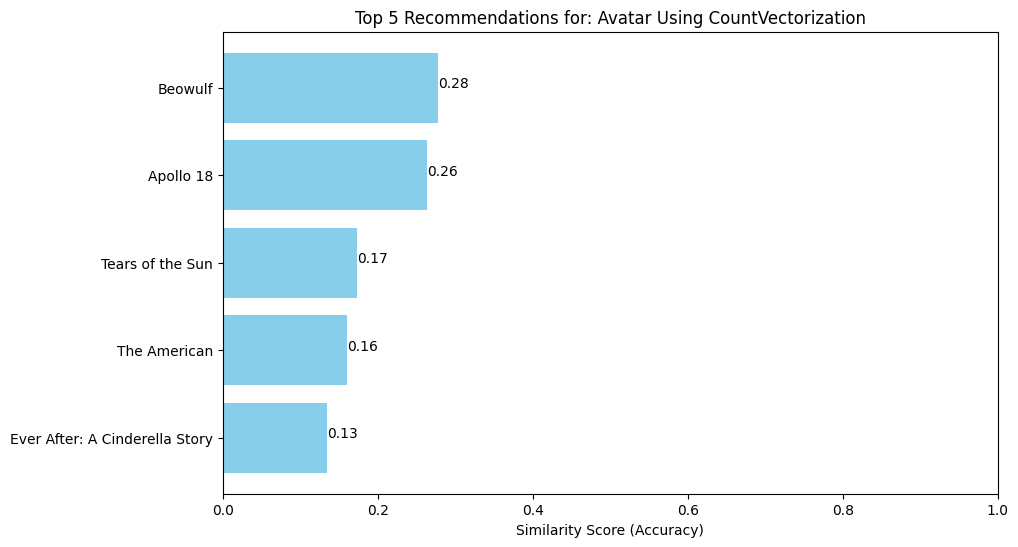

In [178]:

def visualize_recommendations(movie_title, new_df, similarity_matrix):
    # 1. Get the index of the movie
    movie_index = new_df[new_df['title'] == movie_title].index[0]
    
    # 2. Get similarity scores and sort them
    distances = similarity_matrix[movie_index]
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    # 3. Extract movie names and their similarity scores
    movie_names = []
    scores = []
    
    for i in movie_list:
        movie_names.append(new_df.iloc[i[0]].title)
        scores.append(i[1])
        
    # 4. Plotting
    plt.figure(figsize=(10, 6))
    plt.barh(movie_names, scores, color='skyblue')
    plt.xlabel('Similarity Score (Accuracy)')
    plt.title(f'Top 5 Recommendations for: {movie_title} Using CountVectorization')
    plt.gca().invert_yaxis()  # Highest score at the top
    plt.xlim(0, 1)  # Similarity is always between 0 and 1
    
    # Adding text labels on the bars
    for index, value in enumerate(scores):
        plt.text(value, index, f'{value:.2f}')
        
    plt.show()

# To use it:
visualize_recommendations('Avatar', new_df, similarity)

In [76]:
# TFIDF 
from sklearn.feature_extraction.text import TfidfVectorizer
Tfidf= TfidfVectorizer ( max_features=5000, stop_words='english')

In [77]:
vectors= Tfidf.fit_transform(new_df['tags']).toarray()

In [78]:
vectors

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4806, 5000))

In [79]:
import nltk

In [80]:
from nltk.stem.porter import PorterStemmer
ps= PorterStemmer()

In [81]:
def stem(text):
    y=[]

    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y) # again converting to list

In [82]:
new_df['tags'].apply(stem)

0       in the 22nd century, a parapleg marin is dispa...
1       captain barbossa, long believ to be dead, ha c...
2       a cryptic messag from bond’ past send him on a...
3       follow the death of district attorney harvey d...
4       john carter is a war-weary, former militari ca...
                              ...                        
4804    el mariachi just want to play hi guitar and ca...
4805    a newlyw couple' honeymoon is upend by the arr...
4806    "signed, sealed, delivered" introduc a dedic q...
4807    when ambiti new york attorney sam is sent to s...
4808    ever sinc the second grade when he first saw h...
Name: tags, Length: 4806, dtype: object

In [83]:
new_df['tags']= new_df['tags'].apply(stem)

C:\Users\HP\AppData\Local\Temp\ipykernel_18928\3021978705.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']= new_df['tags'].apply(stem)


In [88]:
from sklearn.metrics.pairwise import cosine_similarity

In [89]:
similarity= cosine_similarity(vectors)

In [90]:
similarity

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.03025225, 0.        ,
        0.01160414],
       [0.        , 0.        , 1.        , ..., 0.02031475, 0.        ,
        0.        ],
       ...,
       [0.        , 0.03025225, 0.02031475, ..., 1.        , 0.0200258 ,
        0.01009783],
       [0.        , 0.        , 0.        , ..., 0.0200258 , 1.        ,
        0.02160581],
       [0.        , 0.01160414, 0.        , ..., 0.01009783, 0.02160581,
        1.        ]], shape=(4806, 4806))

In [91]:
def recommend (movie):
    # Find the index of the movie in my dataframe
    movie_index = new_df[new_df['title'] ==movie].index[0]
    # Get the row of similarity scores for that movie
    distances = similarity [movie_index]
    #sort the distances in descending order and pick the top 5 (excluding the movie itself)
    movies_list= sorted(list (enumerate(distances)),reverse=True,key=lambda x:x[1])[1:6]
    
    for i in movies_list:
        print (new_df.iloc[i[0]].title)

In [92]:
recommend('Avatar')

Apollo 18
The Inhabited Island
The Matrix
Tears of the Sun
The Adventures of Pluto Nash


In [93]:
recommend('Cinderella')

Ella Enchanted
Happily N'Ever After
Confessions of a Teenage Drama Queen
Peaceful Warrior
Hidden Away


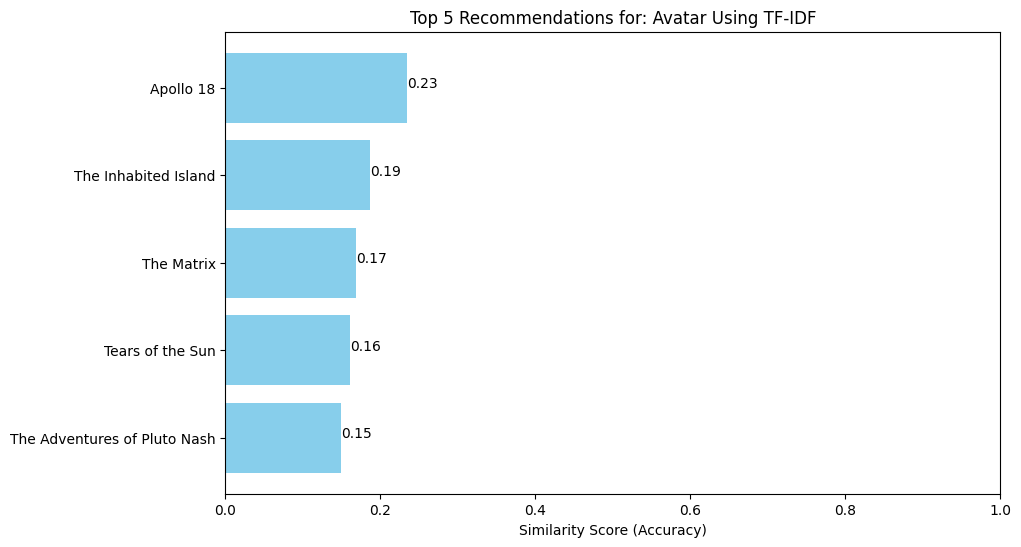

In [95]:

def visualize_recommendations(movie_title, new_df, similarity_matrix):
    # 1. Get the index of the movie
    movie_index = new_df[new_df['title'] == movie_title].index[0]
    
    # 2. Get similarity scores and sort them
    distances = similarity_matrix[movie_index]
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    # 3. Extract movie names and their similarity scores
    movie_names = []
    scores = []
    
    for i in movie_list:
        movie_names.append(new_df.iloc[i[0]].title)
        scores.append(i[1])
        
    # 4. Plotting
    plt.figure(figsize=(10, 6))
    plt.barh(movie_names, scores, color='skyblue')
    plt.xlabel('Similarity Score (Accuracy)')
    plt.title(f'Top 5 Recommendations for: {movie_title} Using TF-IDF')
    plt.gca().invert_yaxis()  # Highest score at the top
    plt.xlim(0, 1)  # Similarity is always between 0 and 1
    
    # Adding text labels on the bars
    for index, value in enumerate(scores):
        plt.text(value, index, f'{value:.2f}')
        
    plt.show()

# To use it:
visualize_recommendations('Avatar', new_df, similarity)

In [96]:
# tag named column and concatinate all the columns [GENRE BOOSTING + TFIDF]

movies['tags']= movies['overview']+ (movies ['genres']*3) + (movies['keywords']*2) + movies['cast'] + movies['crew']

In [97]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 1, 4, 6, 3, ,, , "", n,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 2, 4, 2...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[[, {, "", i, d, "", :, , 1, 2, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 2, 7, 0, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 4, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 4, 7, 0, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 1, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 8, 4, 9, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 2, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[[, {, "", i, d, "", :, , 2, 8, ,, , "", n, a, m,...","[[, {, "", i, d, "", :, , 8, 1, 8, ,, , "", n, a,...","[[, {, "", c, a, s, t, _, i, d, "", :, , 5, ,, ,...","[[, {, "", c, r, e, d, i, t, _, i, d, "", :, , ""...","[John, Carter, is, a, war-weary,, former, mili..."


In [98]:
new_df= movies[['movie_id', 'title', 'tags']]
new_df

,movie_id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
...,...,...,...
4804,9367,El Mariachi,"[El, Mariachi, just, wants, to, play, his, gui..."
4805,72766,Newlyweds,"[A, newlywed, couple's, honeymoon, is, upended..."
4806,231617,"Signed, Sealed, Delivered","[""Signed,, Sealed,, Delivered"", introduces, a,..."
4807,126186,Shanghai Calling,"[When, ambitious, New, York, attorney, Sam, is..."


In [99]:
# converting list into string
new_df['tags']= new_df['tags'].apply(lambda x: " ".join(x))

C:\Users\HP\AppData\Local\Temp\ipykernel_18928\1313414460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']= new_df['tags'].apply(lambda x: " ".join(x))


In [100]:
# convert into lowercase
new_df['tags']= new_df['tags'].apply(lambda x:x.lower())

C:\Users\HP\AppData\Local\Temp\ipykernel_18928\79500122.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']= new_df['tags'].apply(lambda x:x.lower())


In [101]:
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer
Tfidf= TfidfVectorizer ( max_features=5000, stop_words='english')

In [103]:
vectors= Tfidf.fit_transform(new_df['tags']).toarray()

In [104]:
vectors

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4806, 5000))

In [105]:
import nltk

In [106]:
from nltk.stem.porter import PorterStemmer
ps= PorterStemmer()

In [107]:
def stem(text):
    y=[]

    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y) # again converting to list

In [108]:
new_df['tags'].apply(stem)

0       in the 22nd century, a parapleg marin is dispa...
1       captain barbossa, long believ to be dead, ha c...
2       a cryptic messag from bond’ past send him on a...
3       follow the death of district attorney harvey d...
4       john carter is a war-weary, former militari ca...
                              ...                        
4804    el mariachi just want to play hi guitar and ca...
4805    a newlyw couple' honeymoon is upend by the arr...
4806    "signed, sealed, delivered" introduc a dedic q...
4807    when ambiti new york attorney sam is sent to s...
4808    ever sinc the second grade when he first saw h...
Name: tags, Length: 4806, dtype: object

In [109]:
new_df['tags']= new_df['tags'].apply(stem)

C:\Users\HP\AppData\Local\Temp\ipykernel_18928\3021978705.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags']= new_df['tags'].apply(stem)


In [110]:
from sklearn.metrics.pairwise import cosine_similarity

In [111]:
similarity= cosine_similarity(vectors)

In [112]:
similarity

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.02961456, 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.02041222, 0.        ,
        0.        ],
       ...,
       [0.        , 0.02961456, 0.02041222, ..., 1.        , 0.02269027,
        0.00979255],
       [0.        , 0.        , 0.        , ..., 0.02269027, 1.        ,
        0.01707684],
       [0.        , 0.        , 0.        , ..., 0.00979255, 0.01707684,
        1.        ]], shape=(4806, 4806))

In [113]:
def recommend (movie):
    # Find the index of the movie in my dataframe
    movie_index = new_df[new_df['title'] ==movie].index[0]
    # Get the row of similarity scores for that movie
    distances = similarity [movie_index]
    #sort the distances in descending order and pick the top 5 (excluding the movie itself)
    movies_list= sorted(list (enumerate(distances)),reverse=True,key=lambda x:x[1])[1:6]
    
    for i in movies_list:
        print (new_df.iloc[i[0]].title)

In [114]:
recommend ('Avatar')

Apollo 18
The American
Beowulf
Tears of the Sun
The Adventures of Pluto Nash


In [233]:
recommend('Cinderella')

Ella Enchanted
Happily N'Ever After
Sense and Sensibility
Hearts in Atlantis
Fly Me to the Moon


In [234]:
recommend ('Batman Begins')

Batman Forever
Batman
Batman
Batman Returns
The Dark Knight Rises


In [235]:
import pickle

In [236]:
#pickle.dump(new_df.to_dict(),open('movie_dict.pkl','wb'))

In [237]:
#pickle.dump(similarity,open('similarity.pkl', 'wb'))

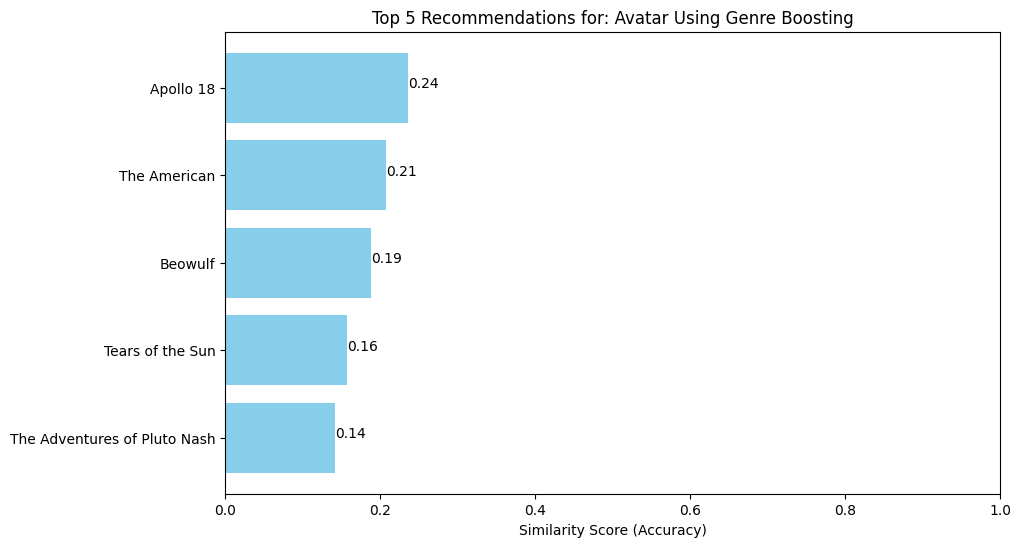

In [117]:

def visualize_recommendations(movie_title, new_df, similarity_matrix):
    # 1. Get the index of the movie
    movie_index = new_df[new_df['title'] == movie_title].index[0]
    
    # 2. Get similarity scores and sort them
    distances = similarity_matrix[movie_index]
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    # 3. Extract movie names and their similarity scores
    movie_names = []
    scores = []
    
    for i in movie_list:
        movie_names.append(new_df.iloc[i[0]].title)
        scores.append(i[1])
        
    # 4. Plotting
    plt.figure(figsize=(10, 6))
    plt.barh(movie_names, scores, color='skyblue')
    plt.xlabel('Similarity Score (Accuracy)')
    plt.title(f'Top 5 Recommendations for: {movie_title} Using Genre Boosting')
    plt.gca().invert_yaxis()  # Highest score at the top
    plt.xlim(0, 1)  # Similarity is always between 0 and 1
    
    # Adding text labels on the bars
    for index, value in enumerate(scores):
        plt.text(value, index, f'{value:.2f}')
        
    plt.show()

# To use it:
visualize_recommendations('Avatar', new_df, similarity)